# Module 2 Data preparation and Baseline Model 

This notebook builds the Module 2 dataset: it merges the 42-feature matrix with the binary Milieuschutz label ("milieu_majoritaet") — and establishes a logistic regression as the baseline classifier for identifying areas that resemble protected ones. 

Then, preprocessing (KNN imputation, log-transformation of skewed features, and standardization, see py.script) is fitted fold-wise inside the cross-validation loop rather than on the full dataset, so that no information from the validation areas leaks into training. 

Cross-validation uses GroupKFold grouped by district because neighbouring planning areas within a district are spatially and administratively correlated, and protection is designated at the district level. Therefore, grouping prevents the model from memorising district-specific patterns and forces it to generalise across districts, giving a spatially honest performance estimate. 

The label is treated as positive-unlabeled (PU) rather than a clean positive/negative split: a planning area marked 1 is confirmed protected, but a 0 only means "not currently designated". It may well be gentrifying and simply not yet (or never) protected, since designation arrives late and each district decides independently. This framing is central to the project, because it reframes the model's confident false positives: finding undesignated areas that look strongly designated is the goal of the project, not an error. 

### 1 Data Loading and Preparation 

In [1]:
#load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from Dataprep import preprocess_fit_transform



In [2]:
#Load the features 
X_df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})

#load the label for Module 2
labels = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#join left on plr_id 
df = X_df.merge(labels[["plr_id", "milieu_majoritaet"]], on="plr_id", how="left")


In [3]:
#sanity check
df.shape


(527, 46)

In [4]:
#sanity check 2 
df.columns


Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_

In [5]:
#sanity check label

LABEL = "milieu_majoritaet"
assert df[LABEL].notna().all(), "Label enthält NaN — unerwartet."
assert set(df[LABEL].unique()) <= {0, 1}, "Label ist nicht binär 0/1."
print(df[LABEL].value_counts(), "\n")

milieu_majoritaet
0    418
1    109
Name: count, dtype: int64 



### Result Discussion: Data Loading and Sanity Checks

Luckily, all dropped planning areas are planning areas that aren't protected. Therefore, the amount of 109 observations of protected planning areas remains and to find 20.7% of the cases is the baseline. 

### 2 Preparation of the Features 

In [6]:
#define columns 
ID_COLS = ["plr_id", "plr_name", "bez"]   
GROUP_COL = "bez"

#Leakage guard: "milieu_anteil" is the continuous share the label is derived from (>50% -> "milieu_majoritaet")
#It must never enter the features. Not currently merged in, but excluded defensively; the assert below is the actual safeguard
LEAKAGE_COLS = ["milieu_anteil"]

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [LABEL] + LEAKAGE_COLS
]
assert not any("milieu" in c for c in feature_cols), \
    "column derived from target is in feature-set — Leakage!"

In [7]:
#calculate skew to define the variables for log-transformation 
skew = df[feature_cols].skew().sort_values(ascending=False)
print("Skewness per feature (descending):\n")
print(skew.to_string())

#Rule of thumb: |skew| > 1 is clearly skewed -> variable for log-transformation 
#log only works for non-negative variables; exclude shares/trends as needed
log_candidates = skew[skew.abs() > 1].index.tolist()
print("\nCandidates (|skew| > 1):", log_candidates)



Skewness per feature (descending):

com_tourism_share_level_2026                                    11.429474
re_dichte_all                                                    3.822843
soc_internal_migration_volume_rate_2025                          3.763845
re_neubau_share                                                  3.556610
com_n_gastro                                                     2.963353
com_share_max_2y_slope                                           2.846477
soc_internal_migration_volume_rate_change_2021_2025              2.754792
com_share_solo_slope                                             2.332406
re_leerstandsquote                                               2.041133
re_brw_niveau                                                    1.924704
com_share_10plus_level_2026                                      1.828611
soc_single_parent_household_share_2024                           1.478141
soc_average_household_size_change_2021_2024                      1.261005
co

In [8]:
#check whether the minimum values of the proposed variables for log transformation are all positive
proposed_log = [
    "com_tourism_share_level_2026", 
    "re_dichte_all", 
    "soc_internal_migration_volume_rate_2025", 
    're_neubau_share', 
    'com_n_gastro', 
    'com_share_max_2y_slope', 
    'soc_internal_migration_volume_rate_change_2021_2025', 
    'com_share_solo_slope', 
    're_leerstandsquote', 
    're_brw_niveau', 
    'com_share_10plus_level_2026', 
    'soc_single_parent_household_share_2024', 
    'soc_average_household_size_change_2021_2024', 
    'com_median_age_slope', 
    'com_share_10plus_slope', 
    'soc_single_person_hh_share_change_2021_2024', 
    'com_gastro_share_slope', 
    'soc_internal_net_migration_rate_change_2021_2025', 
    'soc_internal_net_migration_rate_2025', 
    'com_entry_rate_slope']

mins = df[proposed_log].min()
print("Minimum per proposed log feature:\n")
print(mins.to_string())

#any negative minimum means log1p is invalid for that column; needs to be dropped
invalid = mins[mins < 0].index.tolist()
print("\nNegative minimum (must NOT log):", invalid)

LOG_COLS = [c for c in proposed_log if c not in invalid]
print("\nFinal LOG_COLS:", LOG_COLS)

Minimum per proposed log feature:

com_tourism_share_level_2026                             0.000000
re_dichte_all                                            0.000000
soc_internal_migration_volume_rate_2025                  0.071000
re_neubau_share                                          0.000000
com_n_gastro                                             0.000000
com_share_max_2y_slope                                  -0.079085
soc_internal_migration_volume_rate_change_2021_2025     -0.281000
com_share_solo_slope                                    -0.030888
re_leerstandsquote                                       0.361197
re_brw_niveau                                          256.493697
com_share_10plus_level_2026                              0.000000
soc_single_parent_household_share_2024                   0.022000
soc_average_household_size_change_2021_2024             -0.200000
com_median_age_slope                                    -2.420077
com_share_10plus_slope                   

In [9]:
#candidates list confirmed, log transform for the proposed ones 

LOG_COLS = [
    "com_tourism_share_level_2026",
    "re_dichte_all",
    "soc_internal_migration_volume_rate_2025",
    "re_neubau_share",
    "com_n_gastro",
    "re_leerstandsquote",
    "re_brw_niveau",
    "com_share_10plus_level_2026",
    "soc_single_parent_household_share_2024",
]


LOG_COLS = [c for c in LOG_COLS if c in feature_cols]

print(f"\n{len(feature_cols)} features, of which {len(LOG_COLS)} were log transformed: {LOG_COLS}")



42 features, of which 9 were log transformed: ['com_tourism_share_level_2026', 're_dichte_all', 'soc_internal_migration_volume_rate_2025', 're_neubau_share', 'com_n_gastro', 're_leerstandsquote', 're_brw_niveau', 'com_share_10plus_level_2026', 'soc_single_parent_household_share_2024']


In [10]:
#safeguard plr_id as string with 8 digits 
df["plr_id"] = df["plr_id"].astype(str).str.zfill(8)

X = df[feature_cols].copy()
y = df[LABEL].astype(int).to_numpy()           
groups = df[GROUP_COL].to_numpy()
plr_ids = df["plr_id"].to_numpy()

# Sanity-Checks 
assert len(X) == len(y) == len(groups) == len(plr_ids)
assert df["plr_id"].is_unique, "plr_id not unambiguous!"
n_pos = int(y.sum())
print(f"\nPositive: {n_pos} | Negative: {len(y) - n_pos} | positive rate: {n_pos/len(y):.1%}")



Positive: 109 | Negative: 418 | positive rate: 20.7%


### 3 The Logarithmic Regression with out-of-Fold loop 

We use an out-of-fold GroupKFold scheme grouped by district so that every planning area is scored by a model that never saw its own district in training. Planning areas within a district are spatially and administratively correlated (and "Milieuschutz" is decided at district level), an ungrouped split would let the model memorise district-specific patterns and report an inflated, spatially dishonest score. 

We report AUC-PR rather than accuracy or ROC-AUC because the label is imbalanced (only 20.7% positive) and, under the positive-unlabeled framing, we care specifically about how well the model ranks the true designated areas near the top. Precision and recall on the positive class, which is exactly what AUC-PR summarises. 

In [11]:
#Per fold: preprocessing via preprocess_fit_transform from Dataprep.py
#fit impute + log + scale on train only, apply to val

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

#build an OOF-Array to get one probability per PLR
oof_prob = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y[train_idx]

    #fold-wise preprocessing (leakage-safe): fit on train, apply to both
    X_train_prep, X_val_prep = preprocess_fit_transform(
        X_train, X_val, feature_cols, LOG_COLS, scale=True
    )

    #LogReg as baseline model: fit on train, predict_proba for val
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train_prep, y_train)
    oof_prob[val_idx] = model.predict_proba(X_val_prep)[:, 1]

    #fold diagnosis: AUC-PR + how many positives per fold 
    fold_ap = average_precision_score(y[val_idx], oof_prob[val_idx])
    n_val = len(val_idx)
    n_pos_val = int(y[val_idx].sum())
    print(f"Fold {fold}: n_val={n_val:3d} | n_pos_val={n_pos_val:2d} | "
          f"pos_rate={n_pos_val/n_val:.1%} | AUC-PR={fold_ap:.3f} | "
          f"Bezirke={np.unique(groups[val_idx])}")

#Check for full OOF-coverage
assert not np.isnan(oof_prob).any(), "Not every PLR has an OOF prediction"

Fold 1: n_val= 96 | n_pos_val=19 | pos_rate=19.8% | AUC-PR=0.609 | Bezirke=['03 - Pankow' '10 - Marzahn-Hellersdorf']
Fold 2: n_val= 92 | n_pos_val= 8 | pos_rate=8.7% | AUC-PR=0.329 | Bezirke=['04 - Charlottenburg-Wilmersdorf' '11 - Lichtenberg']
Fold 3: n_val=125 | n_pos_val=19 | pos_rate=15.2% | AUC-PR=0.571 | Bezirke=['01 - Mitte' '09 - Treptow-Köpenick' '12 - Reinickendorf']
Fold 4: n_val= 91 | n_pos_val=17 | pos_rate=18.7% | AUC-PR=0.789 | Bezirke=['05 - Spandau' '07 - Tempelhof-Schöneberg']
Fold 5: n_val=123 | n_pos_val=46 | pos_rate=37.4% | AUC-PR=0.877 | Bezirke=['02 - Friedrichshain-Kreuzberg' '06 - Steglitz-Zehlendorf'
 '08 - Neukölln']


In [12]:
oof_df = pd.DataFrame({
    "plr_id": plr_ids,
    "y_true": y,
    "oof_prob": oof_prob,
})

overall_ap = average_precision_score(y, oof_prob)
baseline_ap = y.mean()
print(f"\nTotal AUC-PR: {overall_ap:.3f}  (Baseline = {baseline_ap:.3f})")

oof_df.to_csv("../../models/M_oof_logreg.csv", index=False) 



Total AUC-PR: 0.628  (Baseline = 0.207)


### Result Discussion: Performance 

The model identifies "milieuschutz" patterns far above chance: the pooled AUC-PR reaches 0.628 vs. a 0.207 baseline. Because the GroupKFold is grouped by district, no district appears in both training and validation. 

Performance varies strongly across folds (0.33–0.88). This spread is driven largely by the number of positives per fold: the weakest fold (Charlottenburg-Wilmersdorf / Lichtenberg) contains only 8 protected PLR, so its AUC-PR sits close to a low baseline and is statistically noisy, while the strongest fold holds 46. 

The spread should therefore be read as a consequence of uneven label distribution across districts under spatial cross-validation, not as strong evidence that districts gentrify by fundamentally different mechanisms. Whether this fold structure reflects the linear model or the data is tested in the next notebook, where XGBoost is run on the identical folds and preprocessing.

In [13]:
#in order to check for amount of positive cases in different district we start a side experiment
#StratifiedGroupKFold: it keeps districts intact but balances positive rate across folds

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob_sgkf = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups), start=1):
    X_train_prep, X_val_prep = preprocess_fit_transform(
        X.iloc[train_idx], X.iloc[val_idx], feature_cols, LOG_COLS, scale=True
    )
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train_prep, y[train_idx])
    oof_prob_sgkf[val_idx] = model.predict_proba(X_val_prep)[:, 1]

    fold_ap = average_precision_score(y[val_idx], oof_prob_sgkf[val_idx])
    n_pos_val = int(y[val_idx].sum())
    print(f"Fold {fold}: n_val={len(val_idx):3d} | n_pos={n_pos_val:2d} | "
          f"pos_rate={n_pos_val/len(val_idx):.1%} | AUC-PR={fold_ap:.3f} | "
          f"districts={np.unique(groups[val_idx])}")

overall_ap_sgkf = average_precision_score(y, oof_prob_sgkf)
print(f"\nStratifiedGroupKFold pooled AUC-PR: {overall_ap_sgkf:.3f}  (GroupKFold was 0.628)")


Fold 1: n_val=112 | n_pos=29 | pos_rate=25.9% | AUC-PR=0.926 | districts=['02 - Friedrichshain-Kreuzberg' '09 - Treptow-Köpenick'
 '12 - Reinickendorf']
Fold 2: n_val= 91 | n_pos=14 | pos_rate=15.4% | AUC-PR=0.626 | districts=['06 - Steglitz-Zehlendorf' '07 - Tempelhof-Schöneberg']
Fold 3: n_val=127 | n_pos=22 | pos_rate=17.3% | AUC-PR=0.754 | districts=['05 - Spandau' '08 - Neukölln' '10 - Marzahn-Hellersdorf']
Fold 4: n_val=100 | n_pos=23 | pos_rate=23.0% | AUC-PR=0.517 | districts=['01 - Mitte' '04 - Charlottenburg-Wilmersdorf']
Fold 5: n_val= 97 | n_pos=21 | pos_rate=21.6% | AUC-PR=0.725 | districts=['03 - Pankow' '11 - Lichtenberg']

StratifiedGroupKFold pooled AUC-PR: 0.668  (GroupKFold was 0.628)


In [14]:
#Evaluation of experiment: a robustness check to see how much the StratifiedGroupKFold score depend on the random split

seed_results = []
for seed in range(10):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    oof = np.full(len(y), np.nan)
    for train_idx, val_idx in sgkf.split(X, y, groups):
        Xtr, Xev = preprocess_fit_transform(
            X.iloc[train_idx], X.iloc[val_idx], feature_cols, LOG_COLS, scale=True
        )
        m = LogisticRegression(class_weight="balanced", max_iter=1000)
        m.fit(Xtr, y[train_idx])
        oof[val_idx] = m.predict_proba(Xev)[:, 1]
    ap = average_precision_score(y, oof)
    seed_results.append(ap)
    print(f"seed={seed}: pooled AUC-PR={ap:.3f}")

seed_results = np.array(seed_results)
print(f"\nmean={seed_results.mean():.3f} | std={seed_results.std():.3f} | "
      f"min={seed_results.min():.3f} | max={seed_results.max():.3f}")
print(f"GroupKFold (deterministic) = 0.628")


seed=0: pooled AUC-PR=0.668
seed=1: pooled AUC-PR=0.668
seed=2: pooled AUC-PR=0.602
seed=3: pooled AUC-PR=0.602
seed=4: pooled AUC-PR=0.668
seed=5: pooled AUC-PR=0.668
seed=6: pooled AUC-PR=0.602
seed=7: pooled AUC-PR=0.668
seed=8: pooled AUC-PR=0.668
seed=9: pooled AUC-PR=0.668

mean=0.649 | std=0.030 | min=0.602 | max=0.668
GroupKFold (deterministic) = 0.628


### Result Discussion: CV Robustness

A StratifiedGroupKFold variant was tested balance out the positive rate across folds. However, it was not adopted: with only 12 districts the fold requires shuffling and the pooled AUC-PR then depends on the random seed, alternating between 0.602 and 0.668 across 10 seeds (mean 0.649). 

The deterministic GroupKFold score of 0.628 is reported instead, as it is reproducible and lies close to the stratified mean — the higher 0.668 is presumed to reflect rather a favourable split, not a genuine performance gain.



### 4 The Logarithmic Regression: the Coefficients' Interpretation  

In [15]:
#LogReg coefficients — magnitude + cross-fold stability
#again preprocessing via preprocess_fit_transform from Dataprep.py, identical to the OOF loop

#Per-fold coefficients for stability
fold_coefs = []
for train_idx, val_idx in gkf.split(X, y, groups):
    Xtr_s, _ = preprocess_fit_transform(
        X.iloc[train_idx], X.iloc[val_idx], feature_cols, LOG_COLS, scale=True
    )
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(Xtr_s, y[train_idx])
    fold_coefs.append(m.coef_[0])

fold_coefs = np.array(fold_coefs)  # shape (5, n_features)

#One model refit on all rows for the headline ranking
X_all_s, _ = preprocess_fit_transform(X, X, feature_cols, LOG_COLS, scale=True)
m_all = LogisticRegression(class_weight="balanced", max_iter=1000)
m_all.fit(X_all_s, y)

#results table: coefficients as headline, mean + spread across folds for stability
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coef_all": m_all.coef_[0],
    "coef_mean_fold": fold_coefs.mean(0),
    "coef_std_fold": fold_coefs.std(0),
})
coef_table["abs_coef"] = coef_table["coef_all"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)

#Flag unstable signs: large effect but flips direction across folds
coef_table["sign_stable"] = (
    np.sign(coef_table["coef_mean_fold"]) == np.sign(coef_table["coef_all"])
) & (coef_table["coef_std_fold"] < coef_table["abs_coef"])

print(coef_table.to_string(index=False))

                                                     feature  coef_all  coef_mean_fold  coef_std_fold  abs_coef  sign_stable
                                             re_neubau_share -0.937316       -0.935377       0.215729  0.937316         True
                                               re_brw_niveau  0.872554        0.854237       0.182305  0.872554         True
                        soc_young_to_middle_adult_share_2025  0.871296        0.867687       0.295164  0.871296         True
                     soc_internal_migration_volume_rate_2025 -0.857790       -0.701213       0.216737  0.857790         True
                             soc_transfer_benefit_share_2024  0.793246        0.907691       0.347989  0.793246         True
            soc_young_to_middle_adult_share_change_2021_2025 -0.675295       -0.652538       0.140333  0.675295         True
                                                com_n_gastro  0.580733        0.621417       0.410544  0.580733         True


In [16]:
#Per-dimension contribution: how much signal does each dimension carry?

coef_table["dim"] = coef_table["feature"].str[:3]  

dim_summary = coef_table.groupby("dim").agg(
    n_features=("feature", "count"),
    mean_abs_coef=("abs_coef", "mean"),
    sum_abs_coef=("abs_coef", "sum"),
    n_in_top10=("feature", lambda s: s.head(10).isin(
        coef_table.head(10)["feature"]).sum()),
).sort_values("mean_abs_coef", ascending=False)

#How many of the top 10 features come from each dimension?
print(dim_summary.to_string())


     n_features  mean_abs_coef  sum_abs_coef  n_in_top10
dim                                                     
re_           8       0.458275      3.666199           3
soc          15       0.427595      6.413926           5
com          19       0.215207      4.088937           2


### Result Discussion - Feature and Dimension Interpretation 

Designated areas are defined less by a single dimension than by a consistent social-and-real-estate signature. On the social side: a higher share of young-to-middle adults, elevated transfer-benefit dependency, and low residential turnover and internal migration volume is among the strongest negative predictors, describing an established rather than high-churn population. On the real-estate side, high land values ("BRW niveau") mark designated areas, while new construction is the single strongest predictor pointing the other way.

Social features dominate the ranking by count, but real-estate features carry the highest average magnitude per feature and the strongest individual signal. Whether this signature is a cause of designation, a criterion for it, or a consequence of prior gentrification cannot be determined from a cross-sectional model.

The positive coefficient on transfer-benefit share 2024 (+0.79) is the most counterintuitive result: naive intuition expects richer areas. But the model measures what characterizes designated areas, and it finds more welfare dependency in already-protected ones. This confirms that planning areas are designated where a vulnerable population still exists and is worth protecting, not after it has turned over.

NB 1: two different objects. The pooled AUC-PR of 0.628 comes from the out-of-fold loop (each area scored by a model that never saw its district) and measures generalisation. The coefficient ranking comes from a single model refit on all areas, since a descriptive ranking wants the most stable estimate. Fold-wise stability is checked separately via coef_std_fold and sign_stable.

NB 2: read blocks, not lone coefficients. Standardized coefficients are comparable in magnitude, but their split within a correlated block is not identifiable, so related real-estate features ("rent level", "BRW niveau", "Altbau share") are read as a block, not in isolation (the strongest pairs, Spearman > 0.8, were already dropped earlier). We anchor interpretation at the dimension level and name individual features only where sign_stable holds and cross-fold error bars are tight.

To confirm the patterns described above and to visualize the coefficients, a plot was created next. 

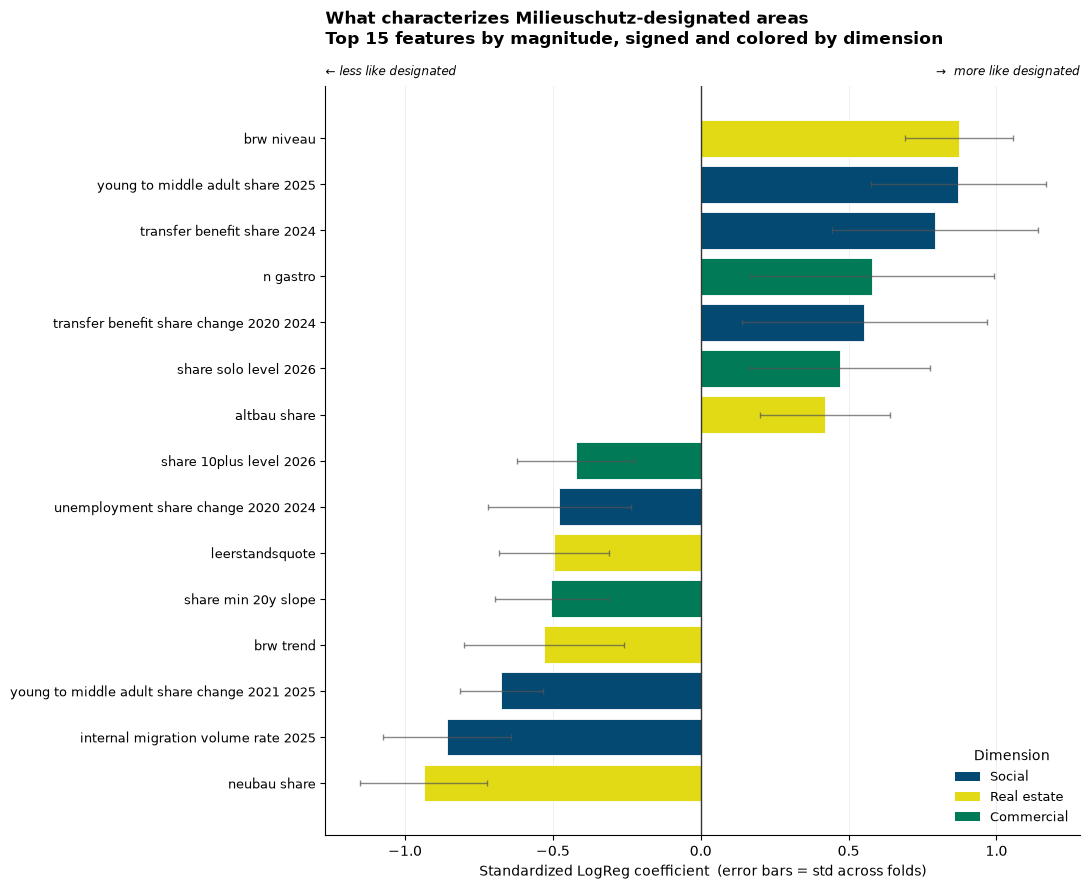

In [17]:
# Plot: LogReg coefficients — magnitude, direction, dimension, stability
TOP_N = 15
plot_df = coef_table.copy()
plot_df["dim"] = plot_df["feature"].str[:3]
plot_df = plot_df.reindex(plot_df["coef_all"].abs().sort_values(ascending=False).index)
plot_df = plot_df.head(TOP_N)
plot_df = plot_df.sort_values("coef_all", ascending=True).reset_index(drop=True)

palette = {"soc": "#044971", "re_": "#E1DA15", "com": "#017A58"}   
labels  = {"soc": "Social", "re_": "Real estate", "com": "Commercial"}
colors  = plot_df["dim"].map(palette)

def pretty(f):
    for p in ("soc_", "re_", "com_"):
        if f.startswith(p):
            f = f[len(p):]
    return f.replace("_", " ")

ylabels = plot_df["feature"].apply(pretty)

fig, ax = plt.subplots(figsize=(11, 9))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["coef_all"], xerr=plot_df["coef_std_fold"], color=colors,
        edgecolor="white", linewidth=0.6,
        error_kw=dict(ecolor="#555555", lw=1, capsize=2.5, alpha=0.7))
ax.axvline(0, color="#333333", lw=1)
ax.set_yticks(y); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel("Standardized LogReg coefficient  (error bars = std across folds)", fontsize=10)
ax.set_title("What characterizes Milieuschutz-designated areas\n"
             f"Top {TOP_N} features by magnitude, signed and colored by dimension",
             fontsize=12, fontweight="bold", loc="left", pad=30)

#directions:
ax.text(1.0, 1.01, "\u2192  more like designated", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8.5, color="black", style="italic", clip_on=False)
ax.text(0.0, 1.01, "\u2190 less like designated", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=8.5, color="black", style="italic", clip_on=False)

legend = [Patch(facecolor=palette[k], label=labels[k]) for k in ["soc", "re_", "com"]]
ax.legend(handles=legend, loc="lower right", frameon=False, fontsize=9, title="Dimension")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../../plots/logreg_coefficients.png", dpi=200, bbox_inches="tight")  
plt.show()

## Plot discussion - Coefficient Chart 

The chart shows the 15 strongest predictors of Milieuschutz designation, measured by standardized logistic-regression coefficients and colored by the three dimensions of gentrification (social, real estate, commercial). 

The features above the zero line make an area statistically more similar to a designated one, while those below make it less similar. The error bars show coefficient stability across the five cross-validation folds. The strongest positive signals are social and real-estate features — a high share of young-to-middle adults, high land values ("BRW niveau"), and a high transfer-benefit share — describing the established profile of already-designated areas. 

The strongest negative signals point the other way: a high share of new construction and strong internal-migration dynamics characterize areas that are not designated. Crucially, several features split by level versus change: land values are positive at level ("BRW niveau") but negative in trend ("BRW trend"). The young-to-middle adult share is positive at level yet negative in its recent change. 

This level-versus-change divergence is central to the early-warning framing, since areas showing upward movement rather than an established state are precisely those the designation label does not yet capture.